# 04 — Zero-Shot Contextomy Detection

Benchmarks four zero-shot approaches on the 100-article English hand-annotated test set.

**Task:** Given a headline quote + best-matching body sentence (+ context), predict `1 = contextomized`, `0 = modified`.

**Target:** Song et al. (2023) QuoteCSE — AUC=0.768 (Korean, supervised).

**Approaches:**
1. Cosine threshold — `best_sim` from Notebook 02, fixed τ=0.5
2. NLI (mDeBERTa) — contradiction score as contextomization probability (Burnham, 2025)
3. GPT-4o direct — classification prompt (Zheng et al., 2023)
4. GPT-4o CoT — chain-of-thought prompt (Wei et al., 2022)

**Primary metric:** AUC. F1 reported at τ=0.5 for all approaches.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv()

THRESHOLD = 0.5  # fixed decision threshold for all approaches

df = pd.read_csv('data/test_set_100.csv')
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)
for col in ['prev_sentence', 'next_sentence']:
    df[col] = df[col].fillna('')

y_true = df['label'].values

print(f"Test set: {len(df)} articles")
print(f"Contextomized: {y_true.sum()}  |  Modified: {(y_true==0).sum()}")
print(f"Sim bins: {df['sim_bin'].value_counts().to_dict()}")

Test set: 100 articles
Contextomized: 15  |  Modified: 85
Sim bins: {'mid': 36, 'low': 33, 'high': 31}


In [2]:
def build_premise(row):
    """Concatenate context window: prev + best body sentence + next."""
    parts = [row['prev_sentence'], row['best_body_sentence'], row['next_sentence']]
    return ' '.join(p for p in parts if p).strip()

def evaluate(y_true, scores, threshold=THRESHOLD):
    """Compute AUC and F1 at fixed threshold. Primary metric is AUC."""
    preds = (scores >= threshold).astype(int)
    auc = roc_auc_score(y_true, scores)
    f1  = f1_score(y_true, preds, zero_division=0)
    print(f"AUC : {auc:.3f}  |  F1 (τ={threshold}) : {f1:.3f}")
    print(classification_report(y_true, preds, target_names=['modified', 'contextomized']))
    return preds, auc, f1

---
## Approach 1 — Cosine Similarity Threshold (τ=0.5)

The cosine similarity between the headline quote embedding and the best-matching body sentence (`best_sim`, Notebook 02) is a direct signal: low similarity → likely contextomized. The score is inverted so that high values indicate contextomization. A fixed threshold τ=0.5 is applied consistently across all approaches.

In [3]:
cosine_scores = 1 - df['best_sim'].values  # invert: high = likely contextomized

cosine_preds, cosine_auc, cosine_f1 = evaluate(y_true, cosine_scores)

AUC : 0.629  |  F1 (τ=0.5) : 0.267
               precision    recall  f1-score   support

     modified       0.87      0.87      0.87        85
contextomized       0.27      0.27      0.27        15

     accuracy                           0.78       100
    macro avg       0.57      0.57      0.57       100
 weighted avg       0.78      0.78      0.78       100



---
## Approach 2 — NLI-based Detection (mDeBERTa)

Contextomy is a semantic faithfulness problem: a modified quote entails the body meaning; a contextomized quote contradicts or diverges from it. We operationalize this as NLI: body context = premise, headline quote = hypothesis. The multilingual `mDeBERTa-v3-base-mnli-xnli` model is applied zero-shot. The **contradiction probability** serves as the contextomization score.

Inference runs in batches on GPU if available, otherwise CPU.

In [4]:
nli_results = pd.read_csv('data/nli_scores.csv')
nli_scores  = nli_results['score_nli'].values
nli_preds   = nli_results['pred_nli'].values
_, nli_auc, nli_f1 = evaluate(y_true, nli_scores)

AUC : 0.549  |  F1 (τ=0.5) : 0.080
               precision    recall  f1-score   support

     modified       0.84      0.89      0.87        85
contextomized       0.10      0.07      0.08        15

     accuracy                           0.77       100
    macro avg       0.47      0.48      0.47       100
 weighted avg       0.73      0.77      0.75       100



---
## Approach 3 — GPT-4o Zero-Shot (Direct Prompt)

Following the LLM-as-judge paradigm (Zheng et al., 2023), GPT-4o receives the headline quote and body context window and outputs a binary label and a probability estimate (0.0–1.0) used for AUC.

In [5]:
import openai
import json
import os
import time

client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

SYSTEM_DIRECT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning. Minor editorial changes (grammar, brevity, pronoun replacement) are acceptable.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

You will receive a headline quote and the body text where it originated.
Output ONLY valid JSON with exactly two fields:
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def classify_direct(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{build_premise(row)}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_DIRECT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=60
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows before committing to full run
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_direct(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=MODIFIED  prob=0.20  |  Someone will get hurt
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  must show more fight
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.90  |  the right person to lead Ukip
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  I think it is a dream


In [6]:
gpt_labels, gpt_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_direct(row)
        gpt_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        gpt_labels.append(0)
        gpt_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

gpt_labels = np.array(gpt_labels)
gpt_scores = np.array(gpt_scores)
gpt_preds, gpt_auc, gpt_f1 = evaluate(y_true, gpt_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.649  |  F1 (τ=0.5) : 0.342
               precision    recall  f1-score   support

     modified       0.95      0.44      0.60        85
contextomized       0.21      0.87      0.34        15

     accuracy                           0.50       100
    macro avg       0.58      0.65      0.47       100
 weighted avg       0.84      0.50      0.56       100



---
## Approach 4 — GPT-4o Chain-of-Thought

Chain-of-thought prompting (Wei et al., 2022) elicits step-by-step reasoning before the final label. The model first states the speaker's intended meaning from the body context, then assesses whether the headline quote preserves it. This decomposition is suited to contextomy detection, where the distortion can be subtle.

In [23]:
SYSTEM_COT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- "step1": What is the speaker's intended meaning in the body context? (1 sentence)
- "step2": Does the headline quote preserve or distort that meaning? (1 sentence)
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def classify_cot(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{build_premise(row)}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_COT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=200
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_cot(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  Someone will get hurt
  gt=0  pred=MODIFIED  prob=0.10  |  must show more fight
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  will put lives at risk
  gt=0  pred=MODIFIED  prob=0.10  |  the right person to lead Ukip
  gt=0  pred=MODIFIED  prob=0.10  |  I think it is a dream


In [24]:
cot_labels, cot_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_cot(row)
        cot_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        cot_labels.append(0)
        cot_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

cot_labels = np.array(cot_labels)
cot_scores = np.array(cot_scores)
cot_preds, cot_auc, cot_f1 = evaluate(y_true, cot_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.710  |  F1 (τ=0.5) : 0.393
               precision    recall  f1-score   support

     modified       0.94      0.60      0.73        85
contextomized       0.26      0.80      0.39        15

     accuracy                           0.63       100
    macro avg       0.60      0.70      0.56       100
 weighted avg       0.84      0.63      0.68       100



---
## Approach 5 — GPT-4o Zero-Shot (Full Article)

Extending Approach 3, the model receives the full article text rather than the three-sentence context window. This tests whether additional documentary context improves classification — a capability unavailable to Song et al.'s contrastive framework, which operates at sentence level. The system prompt is identical; only the input scope changes.

In [9]:
client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

def classify_full_direct(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nFULL ARTICLE: "{str(row["full_text"])[:6000]}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_DIRECT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=60
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows before committing to full run
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_full_direct(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  Someone will get hurt
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  must show more fight
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.95  |  the right person to lead Ukip
  gt=0  pred=CONTEXTOMIZED  prob=0.85  |  I think it is a dream


In [10]:
gpt_full_labels, gpt_full_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_full_direct(row)
        gpt_full_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_full_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        gpt_full_labels.append(0)
        gpt_full_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

gpt_full_labels = np.array(gpt_full_labels)
gpt_full_scores = np.array(gpt_full_scores)
gpt_full_preds, gpt_full_auc, gpt_full_f1 = evaluate(y_true, gpt_full_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.680  |  F1 (τ=0.5) : 0.370
               precision    recall  f1-score   support

     modified       1.00      0.40      0.57        85
contextomized       0.23      1.00      0.37        15

     accuracy                           0.49       100
    macro avg       0.61      0.70      0.47       100
 weighted avg       0.88      0.49      0.54       100



---
## Approach 6 — GPT-4o Chain-of-Thought (Full Article)

Combining full-article context with chain-of-thought reasoning (Wei et al., 2022). If contextomization relies on omitting broader meaning that is recoverable from the article but not the immediate context window, this approach should capture it where Approach 5 cannot.

In [11]:
def classify_full_cot(row):
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nFULL ARTICLE: "{str(row["full_text"])[:6000]}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_COT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=200
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

# Pilot on 5 rows
print("Pilot (5 rows):")
for _, row in df.head(5).iterrows():
    label, prob = classify_full_cot(row)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {row['headline_quote'][:70]}")
    time.sleep(0.3)

Pilot (5 rows):
  gt=0  pred=CONTEXTOMIZED  prob=0.90  |  Someone will get hurt
  gt=0  pred=MODIFIED  prob=0.10  |  must show more fight
  gt=0  pred=MODIFIED  prob=0.30  |  will put lives at risk
  gt=0  pred=CONTEXTOMIZED  prob=0.80  |  the right person to lead Ukip
  gt=0  pred=MODIFIED  prob=0.10  |  I think it is a dream


In [12]:
cot_full_labels, cot_full_scores = [], []

for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_full_cot(row)
        cot_full_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_full_scores.append(prob)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        cot_full_labels.append(0)
        cot_full_scores.append(0.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100 done")
    time.sleep(0.3)

cot_full_labels = np.array(cot_full_labels)
cot_full_scores = np.array(cot_full_scores)
cot_full_preds, cot_full_auc, cot_full_f1 = evaluate(y_true, cot_full_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.588  |  F1 (τ=0.5) : 0.290
               precision    recall  f1-score   support

     modified       0.89      0.48      0.63        85
contextomized       0.19      0.67      0.29        15

     accuracy                           0.51       100
    macro avg       0.54      0.57      0.46       100
 weighted avg       0.79      0.51      0.58       100



---
## Results Summary

Comparison table mirroring Song et al. (2023) Table 2. AUC is the primary metric. F1 is reported at fixed τ=0.5.

In [25]:
results = pd.DataFrame([
    {'Method': 'BERT (Song et al., Korean)',           'AUC': 0.662, 'F1': 0.665, 'Setting': 'supervised'},
    {'Method': 'BERT fine-tune (Song et al., Korean)', 'AUC': 0.749, 'F1': 0.754, 'Setting': 'supervised'},
    {'Method': 'QuoteCSE (Song et al., Korean)',       'AUC': 0.768, 'F1': 0.770, 'Setting': 'supervised'},
    {'Method': 'Cosine τ=0.5 (ours)',                  'AUC': round(cosine_auc, 3), 'F1': round(cosine_f1, 3), 'Setting': 'zero-shot'},
    {'Method': 'mDeBERTa NLI (ours)',                  'AUC': round(nli_auc, 3),    'F1': round(nli_f1, 3),    'Setting': 'zero-shot'},
    {'Method': 'GPT-4o direct (ours)',                 'AUC': round(gpt_auc, 3),    'F1': round(gpt_f1, 3),    'Setting': 'zero-shot'},
    {'Method': 'GPT-4o CoT (ours)',                    'AUC': round(cot_auc, 3),    'F1': round(cot_f1, 3),    'Setting': 'zero-shot'},
    {'Method': 'GPT-4o direct, full text (ours)',  'AUC': round(gpt_full_auc, 3), 'F1': round(gpt_full_f1, 3), 'Setting': 'zero-shot'},
    {'Method': 'GPT-4o CoT, full text (ours)',      'AUC': round(cot_full_auc, 3), 'F1': round(cot_full_f1, 3), 'Setting': 'zero-shot'},
])

print(results.to_string(index=False))

                              Method   AUC    F1    Setting
          BERT (Song et al., Korean) 0.662 0.665 supervised
BERT fine-tune (Song et al., Korean) 0.749 0.754 supervised
      QuoteCSE (Song et al., Korean) 0.768 0.770 supervised
                 Cosine τ=0.5 (ours) 0.629 0.267  zero-shot
                 mDeBERTa NLI (ours) 0.549 0.080  zero-shot
                GPT-4o direct (ours) 0.649 0.342  zero-shot
                   GPT-4o CoT (ours) 0.710 0.393  zero-shot
     GPT-4o direct, full text (ours) 0.680 0.370  zero-shot
        GPT-4o CoT, full text (ours) 0.588 0.290  zero-shot


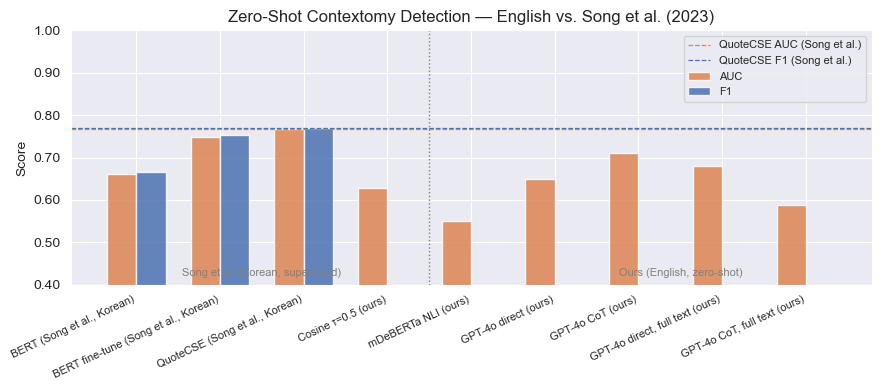

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(len(results)), 0.35

ax.bar(x - w/2, results['AUC'], w, label='AUC', color='#DD8452', alpha=0.85)
ax.bar(x + w/2, results['F1'],  w, label='F1',  color='#4C72B0', alpha=0.85)

ax.axhline(0.768, color='#DD8452', linestyle='--', linewidth=0.9, label='QuoteCSE AUC (Song et al.)')
ax.axhline(0.770, color='#4C72B0', linestyle='--', linewidth=0.9, label='QuoteCSE F1 (Song et al.)')
ax.axvline(3.5, color='grey', linestyle=':', linewidth=1)
ax.text(1.5, 0.42, 'Song et al. (Korean, supervised)', ha='center', fontsize=8, color='grey')
ax.text(6.5, 0.42, 'Ours (English, zero-shot)', ha='center', fontsize=8, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(results['Method'], rotation=25, ha='right', fontsize=8)
ax.set_ylim(0.4, 1.0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Score')
ax.set_title('Zero-Shot Contextomy Detection — English vs. Song et al. (2023)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('data/results_comparison.png', dpi=150)
plt.show()

---
## Error Analysis

Error breakdown by similarity bin (low / mid / high) for the best-performing model. Reveals whether the model struggles more with subtle (mid-sim) or obvious (low-sim) contextomization.

In [27]:
# Automatically select best approach by AUC
all_approaches = {
    'cosine':   (cosine_preds, cosine_scores, cosine_auc),
    'nli':      (nli_preds,    nli_scores,    nli_auc),
    'gpt':      (gpt_preds,    gpt_scores,    gpt_auc),
    'cot':      (cot_preds,    cot_scores,    cot_auc),
    'gpt_full': (gpt_full_preds, gpt_full_scores, gpt_full_auc),
    'cot_full': (cot_full_preds, cot_full_scores, cot_full_auc),
}

best_name = max(all_approaches, key=lambda k: all_approaches[k][2])
best_preds, best_scores, _ = all_approaches[best_name]
print(f"Best approach by AUC: {best_name}")

df_eval = df.copy()
df_eval['pred']    = best_preds
df_eval['correct'] = (df_eval['pred'] == df_eval['label']).astype(int)
df_eval['error_type'] = 'correct'
df_eval.loc[(df_eval['pred']==1) & (df_eval['label']==0), 'error_type'] = 'FP'
df_eval.loc[(df_eval['pred']==0) & (df_eval['label']==1), 'error_type'] = 'FN'

print("Accuracy by similarity bin:")
print(df_eval.groupby('sim_bin')['correct'].mean().round(3))
print()

fp = df_eval[df_eval['error_type'] == 'FP']
fn = df_eval[df_eval['error_type'] == 'FN']
print(f"False Positives (predicted contextomized, was modified) : {len(fp)}")
print(f"False Negatives (predicted modified, was contextomized) : {len(fn)}")

Best approach by AUC: cot
Accuracy by similarity bin:
sim_bin
high    0.774
low     0.455
mid     0.667
Name: correct, dtype: float64

False Positives (predicted contextomized, was modified) : 34
False Negatives (predicted modified, was contextomized) : 3


In [28]:
cols = ['headline_quote', 'best_body_sentence', 'best_sim', 'sim_bin', 'label', 'notes']
fn[cols].to_csv('data/false_negatives.csv', index=False)
fn[cols]

,headline_quote,best_body_sentence,best_sim,sim_bin,label,notes
9,We lived off rats and birds,Story highlights Hostage says he lived off bus...,0.3789,low,1,[hand-v2] FABRICATION: body says hostage 'live...
49,Probe Origins of Dark Matter and Extraterrestr...,The missions to the South Pole are intended to...,0.8014,high,1,[hand-v2-revisit] FABRICATED QUOTE: HQ in quot...
54,We will pay to park outside our homes,Angry residents of Oxford Street want to be ab...,0.6474,mid,1,[hand-v2-revisit] FABRICATED 'WE' QUOTE: headl...


In [29]:
# Load predictions and inspect GPT CoT errors
df_eval = pd.read_csv('data/test_set_predictions.csv')

# Look at high-confidence wrong predictions
wrong = df_eval[df_eval['pred_cot'] != df_eval['label']].copy()
wrong['confidence'] = wrong['score_cot'].apply(lambda x: max(x, 1-x))
wrong.sort_values('confidence', ascending=False)[
    ['headline_quote', 'best_body_sentence', 'label', 
     'pred_cot', 'score_cot', 'sim_bin']
].head(20)

,headline_quote,best_body_sentence,label,pred_cot,score_cot,sim_bin
52,divorce and keep all the assets,One of Britain’s closest EU allies has likened...,0,1,0.95,low
88,I nearly died of a heart attack,"DALE Fortescue ""nearly died of a heart attack”...",0,1,0.95,low
75,Fantastic work from the referee,Alluding to referee Mark Clattenburg’s decisio...,0,1,0.95,mid
26,I ate something bad ... humans,"WEST PALM BEACH, Fla. (AP) — The Florida colle...",0,1,0.95,low
85,should avoid processed meats and leafy greens,Migraine sufferers should avoid eating process...,0,1,0.95,mid
63,Everyone take a cold shower,"""The first thing I think is that everyone need...",0,1,0.95,mid
77,either best or worst thing,Professor Stephen Hawking has warned that the ...,0,1,0.90,low
93,no one cares what men do to women,No one cares what men do to you.,0,1,0.90,high
73,A system that defies imagination,"“So the idea of 2 million to 3 million, whethe...",0,1,0.90,mid
58,we were wrong to trust you,Turning to 21-year-old Kyle Mitchell Dumesny i...,0,1,0.90,low


In [30]:
from sklearn.metrics import confusion_matrix

def sensitivity_specificity(y_true, preds):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn)  # recall on contextomized
    specificity = tn / (tn + fp)  # recall on modified
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"Sensitivity (recall on contextomized) : {sensitivity:.3f}")
    print(f"Specificity (recall on modified)       : {specificity:.3f}")
    print(f"Precision (contextomized)              : {precision:.3f}")
    return sensitivity, specificity, precision

print("=== Cosine ===")
sensitivity_specificity(y_true, cosine_preds)
print("\n=== NLI ===")
sensitivity_specificity(y_true, nli_preds)
print("\n=== GPT-4o direct, context ===")
sensitivity_specificity(y_true, gpt_preds)
print("\n=== GPT-4o CoT, context ===")
sensitivity_specificity(y_true, cot_preds)
print("\n=== GPT-4o direct, full ===")
sensitivity_specificity(y_true, gpt_full_preds)
print("\n=== GPT-4o CoT, full ===")
sensitivity_specificity(y_true, cot_full_preds)

=== Cosine ===
Sensitivity (recall on contextomized) : 0.267
Specificity (recall on modified)       : 0.871
Precision (contextomized)              : 0.267

=== NLI ===
Sensitivity (recall on contextomized) : 0.067
Specificity (recall on modified)       : 0.894
Precision (contextomized)              : 0.100

=== GPT-4o direct, context ===
Sensitivity (recall on contextomized) : 0.867
Specificity (recall on modified)       : 0.435
Precision (contextomized)              : 0.213

=== GPT-4o CoT, context ===
Sensitivity (recall on contextomized) : 0.800
Specificity (recall on modified)       : 0.600
Precision (contextomized)              : 0.261

=== GPT-4o direct, full ===
Sensitivity (recall on contextomized) : 1.000
Specificity (recall on modified)       : 0.400
Precision (contextomized)              : 0.227

=== GPT-4o CoT, full ===
Sensitivity (recall on contextomized) : 0.667
Specificity (recall on modified)       : 0.482
Precision (contextomized)              : 0.185


(0.6666666666666666, 0.4823529411764706, 0.18518518518518517)

---
## Save All Predictions

In [17]:
df_eval['pred_cosine']      = cosine_preds
df_eval['pred_nli']         = nli_preds
df_eval['pred_gpt']         = gpt_preds
df_eval['pred_cot']         = cot_preds
df_eval['pred_gpt_full']    = gpt_full_preds
df_eval['pred_cot_full']    = cot_full_preds
df_eval['score_cosine']     = cosine_scores
df_eval['score_nli']        = nli_scores
df_eval['score_gpt']        = gpt_scores
df_eval['score_cot']        = cot_scores
df_eval['score_gpt_full']   = gpt_full_scores
df_eval['score_cot_full']   = cot_full_scores

df_eval.to_csv('data/test_set_predictions.csv', index=False)
print("Saved: data/test_set_predictions.csv")
print()
print(results.to_string(index=False))

Saved: data/test_set_predictions.csv

                              Method   AUC    F1    Setting
          BERT (Song et al., Korean) 0.662 0.665 supervised
BERT fine-tune (Song et al., Korean) 0.749 0.754 supervised
      QuoteCSE (Song et al., Korean) 0.768 0.770 supervised
                 Cosine τ=0.5 (ours) 0.629 0.267  zero-shot
                 mDeBERTa NLI (ours) 0.549 0.080  zero-shot
                GPT-4o direct (ours) 0.649 0.342  zero-shot
                   GPT-4o CoT (ours) 0.672 0.393  zero-shot
     GPT-4o direct, full text (ours) 0.680 0.370  zero-shot
        GPT-4o CoT, full text (ours) 0.588 0.290  zero-shot


In [31]:
import pickle
import pandas as pd

with open('data/contextomized_quote.pkl', 'rb') as f:
    data = pickle.load(f)

# Check what type it is
print(type(data))

# If it's a DataFrame
if isinstance(data, pd.DataFrame):
    print(data.shape)
    print(data.columns.tolist())
    print(data.head(2))

# If it's a dict
elif isinstance(data, dict):
    print(data.keys())

# If it's a list
elif isinstance(data, list):
    print(len(data))
    print(data[0])

<class 'pandas.DataFrame'>
(1600, 6)
['headline_quote', 'body_quotes', 'headline', 'body', 'url', 'label']
           headline_quote                                        body_quotes  \
0  [한화그룹 비선조직이 비자금 조성 주도]  [한화증권 10여개 지점 동원 모두 300억 500억원 조성, 우리와 무관 휴면계좌...   
1   [한국, 올해 국민소득 2만불 재돌파]  [올해 1인당 국민소득의 경우 2만달러 돌파는 무난할 것으로 예상하고 있다, 3만달...   

                    headline  \
0     “한화그룹 비선조직이 비자금 조성 주도”   
1  IMF "한국, 올해 국민소득 2만불 재돌파"   

                                                body  \
0  \n\t<!-- 본문 내용 -->\n\t<!-- TV플레이어 -->\n\n<!-- ...   
1  \n\t<!-- 본문 내용 -->\n\t<!-- TV플레이어 -->\n\n<!-- ...   

                                                 url  label  
0  https://news.naver.com/main/ranking/read.nhn?r...    1.0  
1  https://news.naver.com/main/ranking/read.nhn?r...    1.0  
